# PyStrata workflow

Import the package directly from this repository's `src` directory.

In [1]:
import sys
from pathlib import Path

# Find the repository root whether Jupyter starts in the root or tests/.
repo_root = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "src" / "pystrata").is_dir()
)

src_path = str(repo_root / "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

import pystrata
from pystrata.output import KappaOutput
import pykooh

print(f"Using pystrata from: {Path(pystrata.__file__).resolve()}")

Using pystrata from: C:\Users\jimxi\GitHub\pystrata\src\pystrata\__init__.py


In [2]:
import numpy as np
import pyrvt
import pandas as pd

In [3]:
Site_Profile_df = pd.read_excel('data/Meloland_Soil_Profile.xlsx',
                               sheet_name = 'Scaled_Dmin_to_Kappa_0.036')

Layers = []
D_min = []
Vs = []
Thickness = []
Profile_Depth = []
mrd_strains = np.logspace(-6,0,num=20)
ModReduc_data = {}
Damping_data = {}
max_freqs = Site_Profile_df['Max Freq']
wave_fracs = Site_Profile_df['Wave Fraction']

In [4]:

for i, (_, row) in enumerate(Site_Profile_df.iterrows()):

    soil_type = pystrata.site.DarendeliSoilType(unit_wt = row['Unit Weight (kN/m3)'],
                                                plas_index=row['PI'],
                                                ocr=1,
                                                stress_mean=row['Stress (kPa)'],
                                                strains = mrd_strains,
                                                damping_min = row['Scaled_D_min (%)']/100)
    
    Layers.append(pystrata.site.Layer(soil_type,row['Thickness (m)'],row['Velocity (m/s)']))

Layers.append(
            pystrata.site.Layer(
                pystrata.site.SoilType(
                    'Reference Rock',
                    25.9,
                    None,
                    0.01
                ),
                0,
                3500
            )
        )

In [5]:
Site_profile = pystrata.site.Profile(Layers)
discretized_Site_profile = Site_profile.auto_discretize(max_freq = max_freqs,wave_frac=wave_fracs)

In [6]:
def calc_kappa(freq,
               FAS,
               freq_range_for_kappa,
               ko_bandwidth = None,
               show_fit = False):
    
    if ko_bandwidth is not None:
        FAS_for_kappa = pykooh.smooth(
            freq_range_for_kappa,
            freq,
            FAS,
            bw = ko_bandwidth
        )
    else:
        FAS_for_kappa = np.interp(freq_range_for_kappa,freq,FAS)

    coeffs = np.polyfit(freq_range_for_kappa,np.log(FAS_for_kappa),1)
    slope, intercept = coeffs
    kappa = -slope / np.pi

    fit_line = np.exp(slope * freq_range_for_kappa + intercept)

    if show_fit:
        return fit_line
    else:
        return kappa

In [7]:
def Kappa_Correction(freq,FAS,Delta_kappa):

    FAS_adj = np.exp(-np.pi*Delta_kappa*freq)*FAS
    
    return FAS_adj

In [ ]:
# Calculation Loop
outputs_freqs = np.logspace(np.log10(0.05),np.log10(50),1000)

Kappa_freqs = outputs_freqs[
    (outputs_freqs >= 10) & (outputs_freqs <= 30)
]

output = pystrata.output.OutputCollection(
    [   
        pystrata.output.FourierAmplitudeSpectrumOutput(
            outputs_freqs,
            pystrata.output.OutputLocation("outcrop", index=0),
            None
        ),
        pystrata.output.FourierComplexSpectrumOutput(
            outputs_freqs,
            pystrata.output.OutputLocation("outcrop", index=0)
        ),
        pystrata.output.KappaOutput(
            Kappa_freqs,
            pystrata.output.OutputLocation("outcrop", index=0),
            None
        ),
        pystrata.output.KappaCorrectFourierAmplitudeSpectrumOutput(
            outputs_freqs,
            Kappa_freqs,
            0.039,
            pystrata.output.OutputLocation("outcrop", index=0),
            None
        ),
        pystrata.output.KappaCorrectedResponseSpectrumOutput(
            outputs_freqs,
            Kappa_freqs,
            0.039,
            pystrata.output.OutputLocation("outcrop", index=0),
            osc_damping=0.05
        ),
        pystrata.output.KappaCorrectFourierComplexSpectrumOutput(
            outputs_freqs,
            Kappa_freqs,
            0.039,
            pystrata.output.OutputLocation("outcrop", index=0)
        ),
    ] 
    )



# motion = pyrvt.motions.StaffordEtAl22Motion(
#         mag= 7,
#         dist_rup = 10,
#         mechanism = "U",
#         method = "continuous",
#         delta_ztor = 0,
#         freqs=np.logspace(np.log10(0.01),np.log10(100),1000),
#         disable_site_amp = True
#     )

motion = pystrata.motion.TimeSeriesMotion.load_at2_file('data/NIS090.AT2')

eql_calc = pystrata.propagation.EquivalentLinearCalculator(strain_limit = 0.5)

In [9]:
p = discretized_Site_profile.copy()

eql_calc(motion, #type:ignore
        p,
        p.location("outcrop", index=-1))

In [10]:
output(eql_calc,
        name = f"test",)

In [11]:
FAS_df = output[0].to_dataframe()

FAS = FAS_df.iloc[:,0].values
freq = FAS_df.index.to_numpy()

In [12]:
kappa_verify = calc_kappa(freq,FAS,Kappa_freqs,None)
kappa = output[2].values

In [13]:
print(kappa_verify)
print(kappa)

0.4879532879856861
[0.48795329]


In [14]:
delta_kappa = kappa - 0.039

In [15]:
fas_kappa_verify = Kappa_Correction(freq,FAS,delta_kappa)

fas_kappa = output[3].values

error = fas_kappa - fas_kappa_verify
print(error)

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.

In [16]:
fcs_kappa = output[5].values

In [19]:
accel_kappa_verify = np.fft.irfft(
    fcs_kappa  / motion.time_step, n=len(motion.accels))

In [20]:
motion_kappa_verify = pystrata.motion.TimeSeriesMotion(
    '',
    '',
    time_step = motion.time_step,
    accels = accel_kappa_verify
)

In [21]:
RS_kappa_verify = motion_kappa_verify.calc_osc_accels(freq,0.05)

In [22]:
RS_kappa = output[4].values


error = RS_kappa -RS_kappa_verify

print(error)

[-1.27262915e-05 -1.29319119e-05 -1.31409698e-05 -1.33532535e-05
 -1.35687162e-05 -1.37874192e-05 -1.40094829e-05 -1.42350551e-05
 -1.44642925e-05 -1.46772442e-05 -1.48650434e-05 -1.50549899e-05
 -1.52672123e-05 -1.55147782e-05 -1.57668528e-05 -1.60235721e-05
 -1.62850722e-05 -1.65514898e-05 -1.68229629e-05 -1.70996316e-05
 -1.73816383e-05 -1.76691282e-05 -1.79622495e-05 -1.82611533e-05
 -1.85515334e-05 -1.87738171e-05 -1.89974829e-05 -1.93181818e-05
 -1.96454138e-05 -1.99793393e-05 -2.03201153e-05 -2.06678927e-05
 -2.10228121e-05 -2.13849981e-05 -2.17545512e-05 -2.19729079e-05
 -2.22789626e-05 -2.26673566e-05 -2.30629582e-05 -2.34654802e-05
 -2.38744445e-05 -2.42617142e-05 -2.44394599e-05 -2.48579384e-05
 -2.52770795e-05 -2.56936639e-05 -2.61032667e-05 -2.63035595e-05
 -2.65723262e-05 -2.69146814e-05 -2.31550297e-05 -2.35690367e-05
 -2.40267306e-05 -2.42701108e-05 -2.46088136e-05 -2.47505193e-05
 -2.49697299e-05 -2.97286658e-05 -3.02082839e-05 -3.11245085e-05
 -3.18153603e-05 -3.25754

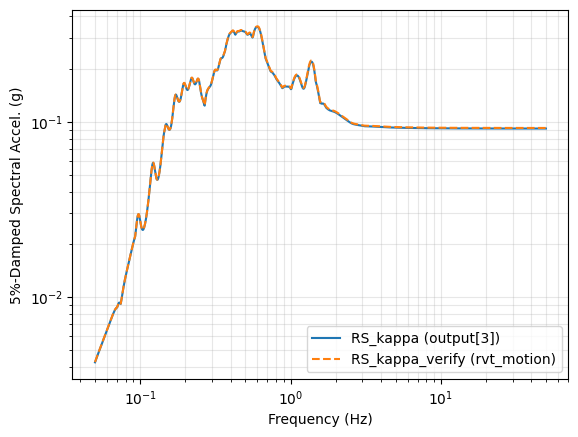

In [23]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.plot(freq, RS_kappa, label="RS_kappa (output[3])")
ax.plot(freq, RS_kappa_verify, "--", label="RS_kappa_verify (rvt_motion)")

ax.set(
    xlabel="Frequency (Hz)",
    xscale="log",
    ylabel="5%-Damped Spectral Accel. (g)",
    yscale="log",
)

ax.legend()

ax.grid(True, which="both", alpha=0.3)

plt.show()